In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [2]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *  

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='create.tcl',
                output_file='create',
                prefix="ops")

In [5]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (133178996128)>


In [6]:
# File: dynamic_quad_plainstrain.py
ops.wipe()

# User-defined variables
matOpt = 2
mass = 2.0
fmass = 1.0
G = 6.0e4
B = 2.4e5
press = 0.0
accMul = 2.0
accNam = "myACC"
accDt = 0.0166
loadBias = 0.07
period = 1.0
deltaT = 0.01
numSteps = 2000
gamma = 0.6
massDamp = 0.0
stiffDamp = 0.002
numXele = 1
numYele = 10
xSize = 1.0
ySize = 1.0

ops.model('basic', '-ndm', 2, '-ndf', 2)

if matOpt == 1:
    ops.nDMaterial('PressureDependMultiYield', 1, 2, mass, G, B, 31.4, 0.1, 80, 0.5,
                   26.5, 0.17, 0.4, 10, 10, 0.015, 1.0)
    ops.updateMaterialStage('-material', 1, '-stage', 0)
    gravY = -9.81 * mass
    gravX = -gravY * loadBias
elif matOpt == 2:
    ops.nDMaterial('PressureDependMultiYield', 1, 2, mass, G, B, 31.4, 0.1, 80, 0.5,
                   26.5, 0.17, 0.4, 10, 10, 0.015, 1.0)
    ops.nDMaterial('FluidSolidPorous', 2, 2, 1, 2.2e6)
    gravY = -9.81 * (mass - fmass)
    gravX = -gravY * loadBias
elif matOpt == 3:
    ops.nDMaterial('PressureIndependMultiYield', 1, 2, mass, 4.e4, 2.e5, 20, 0.1)
    ops.nDMaterial('FluidSolidPorous', 3, 2, 1, 2.2e6)
    ops.updateMaterialStage('-material', 1, '-stage', 0)
    ops.updateMaterialStage('-material', 3, '-stage', 0)
    gravY = -9.81 * (mass - fmass)
    gravX = -gravY * loadBias
elif matOpt == 4:
    ops.nDMaterial('ElasticIsotropic', 4, 2000, 0.3, mass)
    gravY = -9.81 * mass
    gravX = -gravY * loadBias

numXnode = numXele + 1
numYnode = numYele + 1

# Nodes
for i in range(1, numXnode + 1):
    for j in range(1, numYnode + 1):
        xdim = (i - 1) * xSize
        ydim = (j - 1) * ySize
        nodeTag = i + (j - 1) * numXnode
        ops.node(nodeTag, xdim, ydim)

# Elements
for i in range(1, numXele + 1):
    for j in range(1, numYele + 1):
        eleTag = i + (j - 1) * numXele
        n1 = i + (j - 1) * numXnode
        n2 = i + (j - 1) * numXnode + 1
        n4 = i + j * numXnode + 1
        n3 = i + j * numXnode
        ops.element('quad', eleTag, n1, n2, n4, n3, 1.0, "PlaneStrain", matOpt, press, 0.0, gravX, gravY)

# Init material stages
for tag in [1, 2]:
    try:
        ops.updateMaterialStage('-material', tag, '-stage', 0)
    except:
        pass

# Fix base
for i in range(1, numXnode + 1):
    ops.fix(i, 1, 1)

# Tie sides
for i in range(1, numYnode):
    node1 = i * numXnode + 1
    node2 = (i + 1) * numXnode
    ops.equalDOF(node1, node2, 1, 2)

# Gravity analysis (elastic)
ops.system('ProfileSPD')
ops.test('NormDispIncr', 1.0e-5, 10, 0)
ops.algorithm('ModifiedNewton')
ops.constraints('Transformation')
ops.integrator('LoadControl', 1.0)
ops.numberer('RCM')
ops.analysis('Static')
ops.analyze(2)


0

In [7]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [8]:

for i in range(1, 10):
    ops.parameter(1000+i, 'element', i, "bulkModulus", '1')
    
if matOpt == 1:
    ops.updateMaterialStage('-material', 1, '-stage', 1)
    for i in range(1, 10):
        ops.updateParameter(1000+i, 40000.0) 
elif matOpt == 2:
    ops.updateMaterialStage('-material', 1, '-stage', 1)
    ops.updateMaterialStage('-material', 2, '-stage', 1)
    for i in range(1, 10):
        ops.updateParameter(1000+i, 40000.0)
elif matOpt == 3:
    ops.updateMaterialStage('-material', 1, '-stage', 1)
    ops.updateMaterialStage('-material', 3, '-stage', 1)


In [9]:
ops.printModel()

Current Domain Information
	Current Time: 2
	Committed Time: 2
NODE DATA: NumNodes: 22

numComponents: 22

 Node: 1
	Coordinates  : 0 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 2
	Coordinates  : 1 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 3
	Coordinates  : 0 1 
	Disps: 0.000108728 -0.000291234 
	 unbalanced Load: 0 0 
	ID : 18 19 


 Node: 4
	Coordinates  : 1 1 
	Disps: 0.000108728 -0.000291234 
	 unbalanced Load: 0 0 
	ID : 18 19 


 Node: 5
	Coordinates  : 0 2 
	Disps: 0.00020601 -0.000551812 
	 unbalanced Load: 0 0 
	ID : 16 17 


 Node: 6
	Coordinates  : 1 2 
	Disps: 0.00020601 -0.000551812 
	 unbalanced Load: 0 0 
	ID : 16 17 


 Node: 7
	Coordinates  : 0 3 
	Disps: 0.000291848 -0.000781734 
	 unbalanced Load: 0 0 
	ID : 14 15 


 Node: 8
	Coordinates  : 1 3 
	Disps: 0.000291848 -0.000781734 
	 unbalanced Load: 0 0 
	ID : 14 15 


 Node: 9
	Coordinates  : 0 4 
	Disps: 0.00036624 -0.000981 
	 unbalanced Load: 0 0 
	ID : 12 13 


 Node: 10
	Coo

In [10]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [11]:
ops.wipeAnalysis()
ops.setTime(0.0)

# --- pattern for dynamic loading ---
ops.timeSeries('Sine', 1, 0.0, 10.0, period, "-factor", accMul)
ops.pattern("UniformExcitation", 1, 1, "-accel",1)

# Recorders
nodeList = [int(numXnode / 2 + i * numXnode) for i in range(numYnode)]
ops.recorder('Node', '-file', 'disp', '-time', '-node', *nodeList, '-dof', 1, 2, '-dT', deltaT, 'disp')
ops.recorder('Node', '-file', 'acc', '-time', '-node', *nodeList, '-dof', 1, 2, '-dT', deltaT, 'accel')

for i in range(1, numYele):
    ele = numXele - numXele // 2 + (i - 1) * numXele
    ops.recorder('Element', '-ele', ele, '-time', '-file', f"stress{i}", 'material', 1, 'stress')
    ops.recorder('Element', '-ele', ele, '-time', '-file', f"strain{i}", 'material', 1, 'strain')
    if matOpt in [2, 3]:
        ops.recorder('Element', '-ele', ele, '-time', '-file', f"press{i}", 'material', 1, 'pressure')

# Dynamic analysis config
ops.constraints('Transformation')
ops.test('NormDispIncr', 1.e-4, 10, 0)
ops.numberer('RCM')
ops.algorithm('Newton')
ops.system('ProfileSPD')
ops.rayleigh(massDamp, 0.0, stiffDamp, 0.0)
beta = (gamma + 0.5) ** 2 / 4
ops.integrator('Newmark', gamma, beta)
ops.analysis('VariableTransient')

startT = tt.time()
ops.analyze(numSteps, deltaT, deltaT / 100, deltaT, 5)
endT = tt.time()

print(f"Execution time: {int(endT - startT)} seconds.")
ops.wipe()

Execution time: 0 seconds.


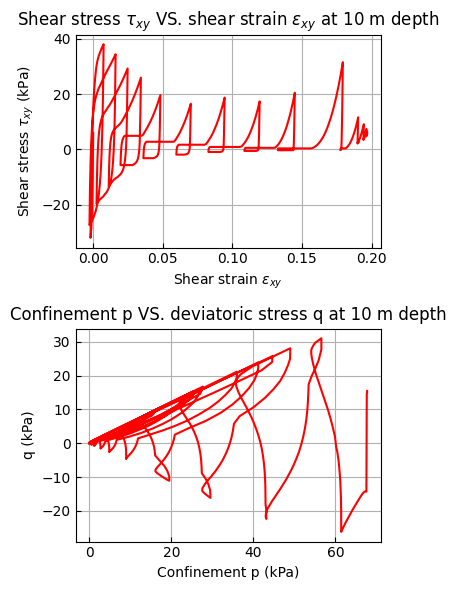

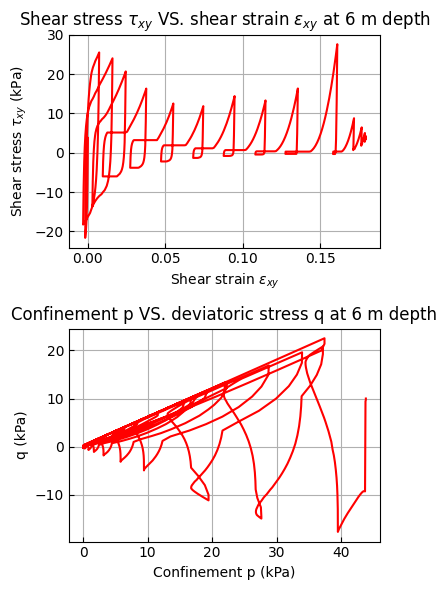

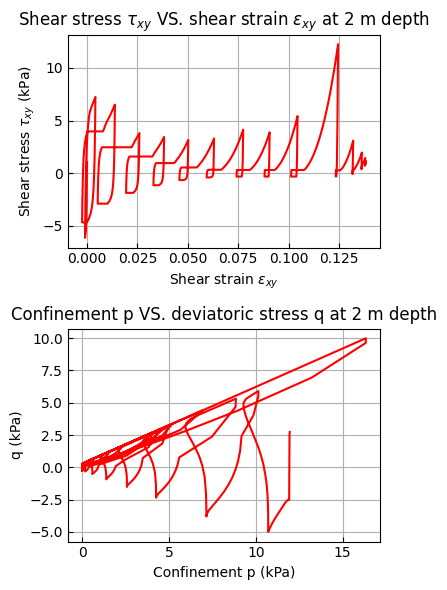

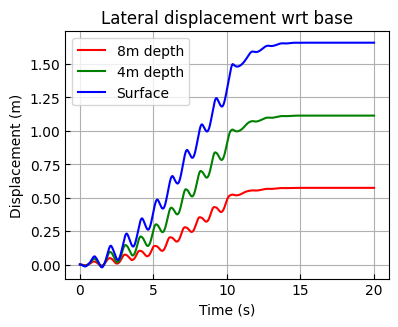

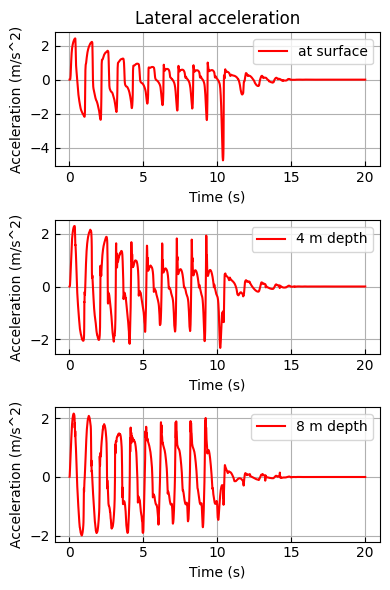

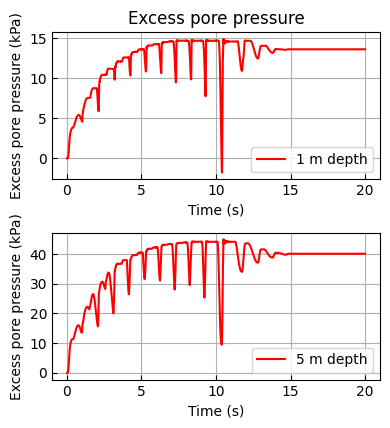

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load the data from files ---
a1 = np.loadtxt('acc')
d1 = np.loadtxt('disp')
p1 = np.loadtxt('press1')
s1 = np.loadtxt('stress2')
e1 = np.loadtxt('strain2')
p6 = np.loadtxt('press6')
s5 = np.loadtxt('stress5')
e5 = np.loadtxt('strain5')
p9 = np.loadtxt('press9')
s9 = np.loadtxt('stress9')
e9 = np.loadtxt('strain9')

# Define global variables
fs = [0.5, 0.2, 4, 6]  # [left, bottom, width, height] for paperposition
accMul = 2

# --- 2. Helper function for p-q calculations and plotting ---
def plot_stress_strain_and_pq(stress_data, strain_data, figure_num, depth, filename):
    """
    Plots the shear stress vs. shear strain and confinement vs. deviatoric stress.

    Parameters:
    - stress_data (np.ndarray): The stress data matrix.
    - strain_data (np.ndarray): The strain data matrix.
    - figure_num (int): The figure number for the plot.
    - depth (str): A string representing the depth for the plot titles.
    - filename (str): The base name for saving the figure.
    """
    # Calculate p (mean normal stress)
    po = (stress_data[:, 1] + stress_data[:, 2]) / 2.0

    # Calculate q (deviatoric stress)
    term1 = (stress_data[:, 1] - stress_data[:, 2])**2
    term2 = (stress_data[:, 2] - stress_data[:, 1])**2
    term4 = 6.0 * stress_data[:, 3]**2
    qo = np.sqrt(term1 + term2 + term4) / 3.0
    
    # Apply the sign of s_xy (stress_data[:, 4]) to qo
    qo = np.sign(stress_data[:, 3]) * qo

    # Create the figure and subplots
    plt.figure(figure_num, figsize=(fs[2], fs[3]))
    plt.clf()
    
    # Subplot 1: Shear stress vs. shear strain
    plt.subplot(2, 1, 1)
    plt.plot(strain_data[:, 3], stress_data[:, 3], 'r')
    plt.title(f'Shear stress $\\tau_{{xy}}$ VS. shear strain $\\epsilon_{{xy}}$ at {depth} depth')
    plt.xlabel('Shear strain $\\epsilon_{{xy}}$')
    plt.ylabel('Shear stress $\\tau_{{xy}}$ (kPa)')
    plt.grid(True)

    # Subplot 2: Confinement vs. deviatoric stress
    plt.subplot(2, 1, 2)
    plt.plot(-po, qo, 'r')
    plt.title(f'Confinement p VS. deviatoric stress q at {depth} depth')
    plt.xlabel('Confinement p (kPa)')
    plt.ylabel('q (kPa)')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'{filename}.jpg', dpi=300)

# --- 3. Plotting the data for different integration points ---
plot_stress_strain_and_pq(s1, e1, 1, '10 m', 'SS_PQ_10m')
plot_stress_strain_and_pq(s5, e5, 5, '6 m', 'SS_PQ_6m')
plot_stress_strain_and_pq(s9, e9, 6, '2 m', 'SS_PQ_2m')

# --- 4. Plotting displacement data ---
plt.figure(2, figsize=(fs[2], fs[3]))
plt.clf()
plt.subplot(2, 1, 1)
plt.plot(d1[:, 0], d1[:, 7], 'r', label='8m depth')
plt.plot(d1[:, 0], d1[:, 13], 'g', label='4m depth')
plt.plot(d1[:, 0], d1[:, 21], 'b', label='Surface')
plt.title('Lateral displacement wrt base')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Disp.jpg', dpi=300)

# --- 5. Plotting acceleration data ---
plt.figure(3, figsize=(fs[2], fs[3]))
plt.clf()

# Interpolate the sine wave. The time range and zero padding are different.
t_sine = np.arange(0, 20.01, 0.01)
s_wave = accMul * np.sin(np.arange(0, 20*np.pi + 1e-9, np.pi/50))
s_padded = np.pad(s_wave, (0, 1000), 'constant')
s_interpolated = np.interp(a1[:, 0], t_sine[:len(s_padded)], s_padded)

# Subplot 1: Surface acceleration
plt.subplot(3, 1, 1)
plt.plot(a1[:, 0], s_interpolated + a1[:, 21], 'r', label='at surface')
plt.title('Lateral acceleration')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

# Subplot 2: 4 m depth acceleration
plt.subplot(3, 1, 2)
plt.plot(a1[:, 0], s_interpolated + a1[:, 13], 'r', label='4 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

# Subplot 3: 8 m depth acceleration
plt.subplot(3, 1, 3)
plt.plot(a1[:, 0], s_interpolated + a1[:, 7], 'r', label='8 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('Acc.jpg', dpi=300)


# --- 6. Plotting pore pressure data ---
plt.figure(4, figsize=(fs[2], fs[3]))
plt.clf()

# Subplot 1: 1 m depth
plt.subplot(3, 1, 1)
plt.plot(p9[:, 0], -p9[:, 1], 'r', label='1 m depth')
plt.title('Excess pore pressure')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure (kPa)')
plt.legend()
plt.grid(True)

# Subplot 2: 5 m depth
plt.subplot(3, 1, 2)
plt.plot(p6[:, 0], -p6[:, 1], 'r', label='5 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure (kPa)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('EPWP.jpg', dpi=300)

plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load the data from files ---
a1 = np.loadtxt('acc')
d1 = np.loadtxt('disp')
p1 = np.loadtxt('press1')
s1 = np.loadtxt('stress2')
e1 = np.loadtxt('strain2')
p6 = np.loadtxt('press6')
s5 = np.loadtxt('stress5')
e5 = np.loadtxt('strain5')
p9 = np.loadtxt('press9')
s9 = np.loadtxt('stress9')
e9 = np.loadtxt('strain9')

# Define global variables
fs = [0.5, 0.2, 4, 6]  # [left, bottom, width, height] for paperposition
accMul = 2

# --- 2. Helper function for p-q calculations and plotting ---
def plot_stress_strain_and_pq(stress_data, strain_data, figure_num, depth, filename):
    """
    Plots the shear stress vs. shear strain and confinement vs. deviatoric stress.

    Parameters:
    - stress_data (np.ndarray): The stress data matrix.
    - strain_data (np.ndarray): The strain data matrix.
    - figure_num (int): The figure number for the plot.
    - depth (str): A string representing the depth for the plot titles.
    - filename (str): The base name for saving the figure.
    """
    # Calculate p (mean normal stress)
    po = (stress_data[:, 1] + stress_data[:, 2] + stress_data[:, 3]) / 3.0

    # Calculate q (deviatoric stress)
    term1 = (stress_data[:, 1] - stress_data[:, 2])**2
    term2 = (stress_data[:, 2] - stress_data[:, 3])**2
    term3 = (stress_data[:, 1] - stress_data[:, 3])**2
    term4 = 6.0 * stress_data[:, 4]**2
    qo = np.sqrt(term1 + term2 + term3 + term4) / 3.0
    
    # Apply the sign of s_xy (stress_data[:, 4]) to qo
    qo = np.sign(stress_data[:, 4]) * qo

    # Create the figure and subplots
    plt.figure(figure_num, figsize=(fs[2], fs[3]))
    plt.clf()
    
    # Subplot 1: Shear stress vs. shear strain
    plt.subplot(2, 1, 1)
    plt.plot(strain_data[:, 3], stress_data[:, 4], 'r')
    plt.title(f'Shear stress $\\tau_{{xy}}$ VS. shear strain $\\epsilon_{{xy}}$ at {depth} depth')
    plt.xlabel('Shear strain $\\epsilon_{{xy}}$')
    plt.ylabel('Shear stress $\\tau_{{xy}}$ (kPa)')
    plt.grid(True)

    # Subplot 2: Confinement vs. deviatoric stress
    plt.subplot(2, 1, 2)
    plt.plot(-po, qo, 'r')
    plt.title(f'Confinement p VS. deviatoric stress q at {depth} depth')
    plt.xlabel('Confinement p (kPa)')
    plt.ylabel('q (kPa)')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'{filename}.jpg', dpi=300)

# --- 3. Plotting the data for different integration points ---
plot_stress_strain_and_pq(s1, e1, 1, '10 m', 'SS_PQ_10m')
plot_stress_strain_and_pq(s5, e5, 5, '6 m', 'SS_PQ_6m')
plot_stress_strain_and_pq(s9, e9, 6, '2 m', 'SS_PQ_2m')

# --- 4. Plotting displacement data ---
plt.figure(2, figsize=(fs[2], fs[3]))
plt.clf()
plt.subplot(2, 1, 1)
plt.plot(d1[:, 0], d1[:, 7], 'r', label='8m depth')
plt.plot(d1[:, 0], d1[:, 13], 'g', label='4m depth')
plt.plot(d1[:, 0], d1[:, 21], 'b', label='Surface')
plt.title('Lateral displacement wrt base')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Disp.jpg', dpi=300)

# --- 5. Plotting acceleration data ---
plt.figure(3, figsize=(fs[2], fs[3]))
plt.clf()

# Interpolate the sine wave. The time range and zero padding are different.
t_sine = np.arange(0, 20.01, 0.01)
s_wave = accMul * np.sin(np.arange(0, 20*np.pi + 1e-9, np.pi/50))
s_padded = np.pad(s_wave, (0, 1000), 'constant')
s_interpolated = np.interp(a1[:, 0], t_sine[:len(s_padded)], s_padded)

# Subplot 1: Surface acceleration
plt.subplot(3, 1, 1)
plt.plot(a1[:, 0], s_interpolated + a1[:, 21], 'r', label='at surface')
plt.title('Lateral acceleration')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

# Subplot 2: 4 m depth acceleration
plt.subplot(3, 1, 2)
plt.plot(a1[:, 0], s_interpolated + a1[:, 13], 'r', label='4 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

# Subplot 3: 8 m depth acceleration
plt.subplot(3, 1, 3)
plt.plot(a1[:, 0], s_interpolated + a1[:, 7], 'r', label='8 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('Acc.jpg', dpi=300)


# --- 6. Plotting pore pressure data ---
plt.figure(4, figsize=(fs[2], fs[3]))
plt.clf()

# Subplot 1: 1 m depth
plt.subplot(3, 1, 1)
plt.plot(p9[:, 0], -p9[:, 1], 'r', label='1 m depth')
plt.title('Excess pore pressure')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure (kPa)')
plt.legend()
plt.grid(True)

# Subplot 2: 5 m depth
plt.subplot(3, 1, 2)
plt.plot(p6[:, 0], -p6[:, 1], 'r', label='5 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure (kPa)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('EPWP.jpg', dpi=300)

plt.show()

IndexError: index 4 is out of bounds for axis 1 with size 4